In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

processed_dir = Path("../data/processed")

train_dir = processed_dir/"train"
val_dir = processed_dir/"validation"
test_dir = processed_dir/"test"

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

# creating tensorflow dataset for training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True                # randomly shuffles the training images before creating batches, prevents the model from learning order of the data
)

# creating tensorflow dataset for validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False      
)

# creating tensorflow dataset for testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

Found 2294 files belonging to 4 classes.
Found 576 files belonging to 4 classes.
Found 394 files belonging to 4 classes.


In [4]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [5]:
print("Train:", train_ds.class_names)
print("Validation:", val_ds.class_names)
print("Test:", test_ds.class_names)

Train: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Validation: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Test: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [6]:
# Optimizing the data pipeline

AUTOTUNE = tf.data.AUTOTUNE
# AUTOTUNE figures out the best numbber of batches of prefetch based on the available CPU, memory and workload

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size = AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(buffer_size = AUTOTUNE)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(buffer_size = AUTOTUNE)
)

- cache() :- Stores the dataset in memory after the first epoch, reducing disk reads and speeding up subsequent epochs.

- shuffle(buffer_size) :- Randomizes the training samples before each epoch, helping the model generalize better. Here, 1000 is the shuffle buffer size.

- prefetch(AUTOTUNE) :- Loads the next batch while the model processes the current one, improving training efficiency.



In [7]:
# Creating the data augmentation pipeline

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),          #Randomly flips images horizontally.
    layers.RandomRotation(0.1),               # Rotates images randomly by up to about ±10%.
    layers.RandomZoom(0.1)                    # Randomly zooms in or out by up to 10%
])

In [8]:
# Model building

model = models.Sequential([
    # Data Preprocessing
    layers.Input(shape= (224, 224, 3)),
    layers.Rescaling(1./255),
    data_augmentation,
    
    # Block 1
    layers.Conv2D(32, (3, 3), activation= "relu"),
    layers.MaxPooling2D(),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation= "relu"),
    layers.MaxPooling2D(),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation= "relu"),
    layers.MaxPooling2D(),
    
    
    # Classifier
    layers.Flatten(),
    layers.Dense(128 , activation= "relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation= "softmax")
])

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model Compilation

model.compile(
    optimizer= "adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/20


c:\Users\kashy\OneDrive\Desktop\coding\Machine Learning\Deep Learning\CNN\brain-tumor-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 560ms/step - accuracy: 0.4677 - loss: 1.1907 - val_accuracy: 0.5712 - val_loss: 0.9499
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 594ms/step - accuracy: 0.5920 - loss: 0.9503 - val_accuracy: 0.6476 - val_loss: 0.8030
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 582ms/step - accuracy: 0.6456 - loss: 0.8402 - val_accuracy: 0.7500 - val_loss: 0.6452
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 583ms/step - accuracy: 0.6892 - loss: 0.7533 - val_accuracy: 0.7431 - val_loss: 0.6126
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 582ms/step - accuracy: 0.6983 - loss: 0.7197 - val_accuracy: 0.7674 - val_loss: 0.5407
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 582ms/step - accuracy: 0.7262 - loss: 0.6651 - val_accuracy: 0.7812 - val_loss: 0.5107
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 587ms/step - accuracy: 0.7319 - loss: 0.6452 - val_accuracy: 0.7344 - val_loss: 0.6465
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 577ms/step - accuracy: 0.7528 - loss: 0.5749 - val_accuracy: 0.803

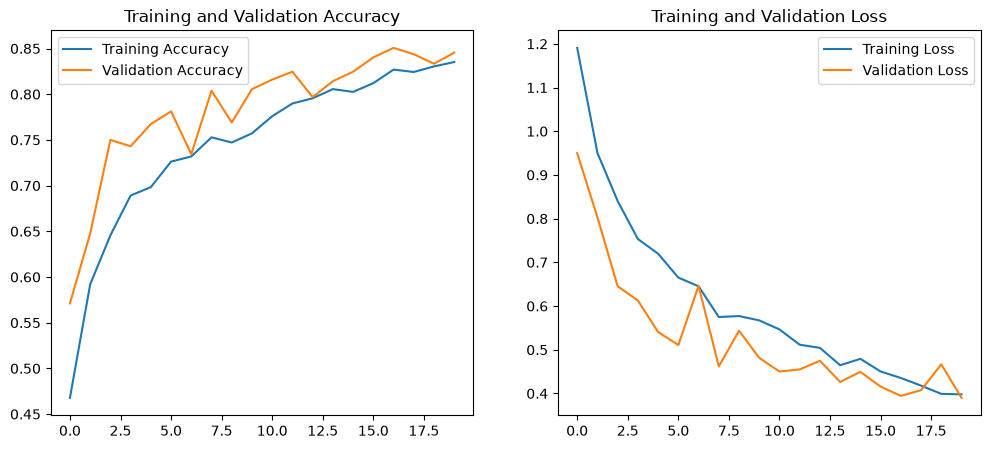

In [12]:
# Plotting training history

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize = (12, 5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label= "Training Accuracy")
plt.plot(epochs_range, val_acc, label = "Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = "Training Loss")
plt.plot(epochs_range, val_loss, label = "Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.show()

In [13]:
# Model Evaluation

test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.5228 - loss: 3.7786
Test Loss : 3.7786
Test Accuracy : 0.5228


In [14]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [15]:
# Saving the trained model

model.save("../models/brain_tumor_cnn_v1.keras")